# Lab 1: Text Corpora and Language Modelling

Welcome to the first lab assignment of INFOMNLP 2026.

This lab is meant to help you get familiar with some language data, and use this data to estimate simple models called N-gram language models.

First, you will use the **Penn Treebank**, which is a collection of newspaper articles from the newspaper
The Wall Street Journal. The idea is to examine the data and notice interesting properties. This will not take more than a few lines of code. The Penn Treebank may be the most widely used corpus in NLP.

Then you will use a corpus consisting of **TedX** talks. This you will use to estimate an **N-gram language model** for different orders of N, and use this for some tasks.

The dataset URLs are in the notebook and certain cells are responsible for downloading them.

The questions marked **Extra** or **Optional** are an additional challenge for those interested in going the extra mile. There are no points for them.

# Rules

You are greatly encouraged to add comments to your code describing what particular lines of code do (in general, a great habit to have in your coding life).
Additionally, please follow these rules when submitting the notebook:

1. Put all code in the cell with the `# YOUR CODE HERE` comment.
2. For theoretical questions, put your solution in the `YOUR ANSWER HERE` or `ANSWER UNDER THIS LINE` cells (and keep the header, if any).
3. Don't change or delete any initially provided cells, either text or code, unless explicitly instructed to do so.
4. Don't delete the comment lines `# TEST...` or edit their code cells. The test cells are for sanity checking. Passing them doesn't necessarily mean that your code is fine.
5. Don't change the names of the provided functions and variables, the arity of funcions, and types of function input/output.
7. Don't clear the output of your code cells.
8. Don't output unnecessary info (e.g., printing variables for debugging purposes). This clutters the notebook and slows down the grading. You can have print() in the code, but comment them out before submitting the notebook.
9. Delete those cells that you inserted for your own debugging/testing purposes.
10. When several lines of code is <font color="red">copied from GenAI</font>, mark them explicitly with commented tags `#<AI>\n code \n#</AI>`.
11. A full exercise solution that appears to be <font color="red">copied from GenAI</font> will receive 0 points.   
10. Don't forget to fill in the **contribution information**.
11. Don't forget to fill in the **work description section** per exercise.
12. Test your code and **make sure we can run your notebook** in the colab environment.
13. A single notebook file (without archiving) per group should be submitted via BrightSpace.

<font color="red">Following these rules helps us to grade the submissions relatively efficiently. If these rules are violated, a submission will be subject to penalty points. A serious breach of these rules in an exercise may result in 0 points.</font>  

# <font color="red">Contributions</font>

~~Delete this text and write instead of it yours:~~
* ~~a list of group members' names (NOT student IDs)~~
* ~~who contributed to which exercises and how. Note that it is important that each member has some contribution to each exercise, e.g., at least reviewing the solutions.~~

YOUR ANSWER HERE [30-50 words]

# General instructions

Before diving into the exercises, keep in mind that the variables defined previously can be reused in the subsequent cells. So there is no need to redefine the same variable in multiple sections, e.g., it is sufficient to read the file in a variable once and later reuse the value of the variable, instead of re-reading the file.   

If your code is too long and uses several code cells instead of a single code cell, rethink how to organize data in variables so that you can easily access the required info. Reading about [list comprehension](https://realpython.com/list-comprehension-python/#leverage-list-comprehensions) can be useful.

Your code will often be evaluated based on its behaviour. So, during the grading some code cells are executed. If code runtime is too long than expected, this will hinder grading.

<font color="red">**The cases similar to the above-mentioned ones will be subject to penalty points.**</font>

<font color="red">**Pay attention to test units**</font> that are either provided as assert cases or as comments. Test units help you by giving you a hint about the correct answer. Note that **passing test units doesn't guarantee the full points** for an exercise because test units are incomplete, and the code might fail on other test units.

# Set up

In [4]:
%matplotlib inline
import matplotlib
import numpy as np
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from itertools import combinations

In [5]:
! rm -rf data # remove if it was downloaded
! mkdir -p data
! wget --no-check-certificate -nv "https://drive.google.com/uc?export=download&id=1hc9V7CIygLdN_4CU2kj6NFnaLGxS8Sqf" -O data/sec02-21.gold.tagged # download the file
! wget --no-check-certificate -nv "https://drive.google.com/uc?export=download&id=1FNQ_2CBlX8k3APufj1kEqtYNx4irCkRk" -O data/sec00.gold.tagged
! wget --no-check-certificate -nv "https://drive.google.com/uc?export=download&id=1XOaH6TmgboOB1O6DtWFgts4afduRd98N" -O data/ted-train.txt
! wget --no-check-certificate -nv "https://drive.google.com/uc?export=download&id=1ypLepyeFY-3PwEhKOhjlHBmdoQmBlUto" -O data/ted-test.txt

2026-04-30 16:20:54 URL:https://drive.usercontent.google.com/download?id=1hc9V7CIygLdN_4CU2kj6NFnaLGxS8Sqf&export=download [8158400/8158400] -> "data/sec02-21.gold.tagged" [1]
2026-04-30 16:20:56 URL:https://drive.usercontent.google.com/download?id=1FNQ_2CBlX8k3APufj1kEqtYNx4irCkRk&export=download [399917/399917] -> "data/sec00.gold.tagged" [1]
2026-04-30 16:20:57 URL:https://drive.usercontent.google.com/download?id=1XOaH6TmgboOB1O6DtWFgts4afduRd98N&export=download [24743290/24743290] -> "data/ted-train.txt" [1]
2026-04-30 16:21:02 URL:https://drive.usercontent.google.com/download?id=1ypLepyeFY-3PwEhKOhjlHBmdoQmBlUto&export=download [25383/25383] -> "data/ted-test.txt" [1]


# Golab variables

In [6]:
PTB_FILES = {'train': 'data/sec02-21.gold.tagged', 'dev': 'data/sec00.gold.tagged'}
TED_FILES = {'train': 'data/ted-train.txt', 'test': 'data/ted-test.txt'}

# 1. Penn treebank

## Ex 1.1 [15pt]

You are provided with a corpus containing tokens with their Part-of-Speech tags (POS-tags for short). The format is
**token|POS** (one sentence per line) and the file name is **sec02-21.gold.tagged**. This data is extracted from Sections 02-21 from the Penn Treebank: these sections are most commonly used for training statistical models like POS taggers and parsers.

Note the **distinction between token & word**. "Token" is a technical term and represents an occurrence of a word. Here, "word" covers both lexical words and other symbols (e.g., punctuations or numbers). Often "word" is called "token type". So, one can say that a token type can have different occurrences and each occurrence is a token.

**[Hint]** **Figure 17.2** in chapter 17 of Jurafsky and Martin (see [here](https://web.stanford.edu/~jurafsky/slp3/17.pdf#page=4)) holds a summary of POS-tags used in the Penn Treebank tagset together with their meaning and some examples.

**[Hint]** The Python library [collections](https://docs.python.org/3.7/library/collections.html) has an object called `Counter` which will come in handy for this exercise.

<font color="red">Avoid redundancy! Read the file once only in subexercise (a) and reuse the read data in the subsequent subexercises.</font>

### (a) Corpus & vocab [3pt]

**Print** the corpus size (i.e. the number of **tokens**).  
**Print** the size of the **vocabulary** of the corpus. Estimate the vocabulary size both by **lowercasing** all the tokens as well as by leaving the tokens in their **original orthography**.  

What is the **advantage** of lowercasing all the tokens in your corpus?  
What is a notable **downside**?  
**Give examples** of the advantage and the downside.

In [7]:
## YOUR CODE HERE ##
# Use PTB_FILES golab var
# TEST: original orthography vocab size = ...10 (i.e., the last two digits of the vocab size are "10")

initial_vocab = Counter()
lower_vocab = Counter()
token_to_tags = defaultdict(set)
sentences: list[list[str]] = []

with open(PTB_FILES['train'], 'r') as ptb:
  for line in ptb:
    pairs = line.strip().split()
    sent = []
    for tp in pairs:
      token, tag = tp.split("|")
      sent.append((token, tag))
      initial_vocab[token] += 1
      token_to_tags[token].add(tag)
      lower_vocab[token.lower()] += 1
    sentences.append(sent)

token_count = sum(initial_vocab.values())
initial_vocab_set = set(initial_vocab.keys())
lower_vocab_set = set(lower_vocab.keys())

print(f"token count: {token_count}")
print(f"initial vocab size: {len(initial_vocab_set)}")
print(f"lowercased vocab size: {len(lower_vocab_set)}")

token count: 929552
initial vocab size: 44210
lowercased vocab size: 39384


<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

The main benefit is reducing data sparsity. Lowercasing unifies variants of the same word,, shrinking the
vocabulary size and ensuring the model doesn't treat sentence-starting words as unique entities. This improves
frequency counts and generalization. As such, The, THE, the and any other combination would be treated as one (the
same) token. A notable downside is you lose the meaning in proper nouns. For example, Apple can refer to both the
company and a fruit and by lowercasing we will lose the meaning of "Apple" as the company.

------
**For the rest of this exercise <font color="red">you should use the original orthography</font> of the data when answering the questions.**

------

### [Extra]

Plot a graph of word frequency versus rank of a word, in this corpus. Does this corpus obey **Zipf’s law**? For a better picture you might need to make the plot horizontally wide or consider an initial cutoff of ranked words.

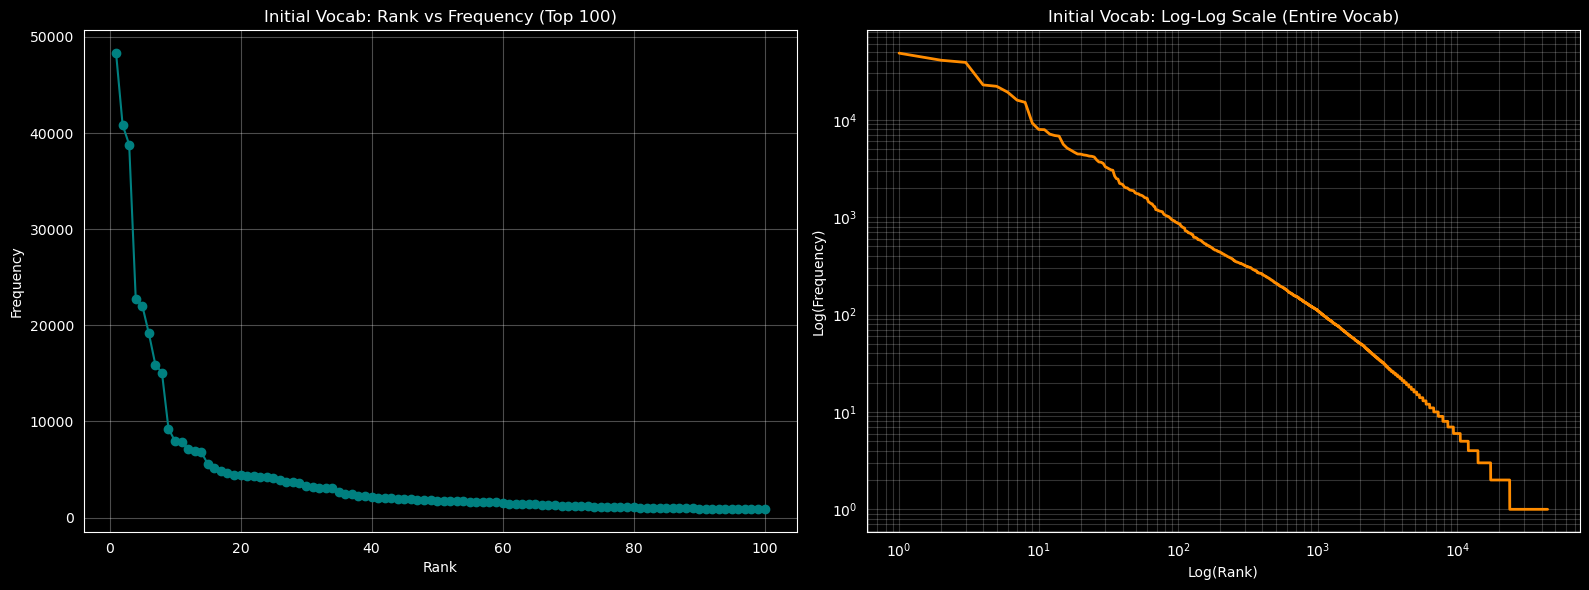

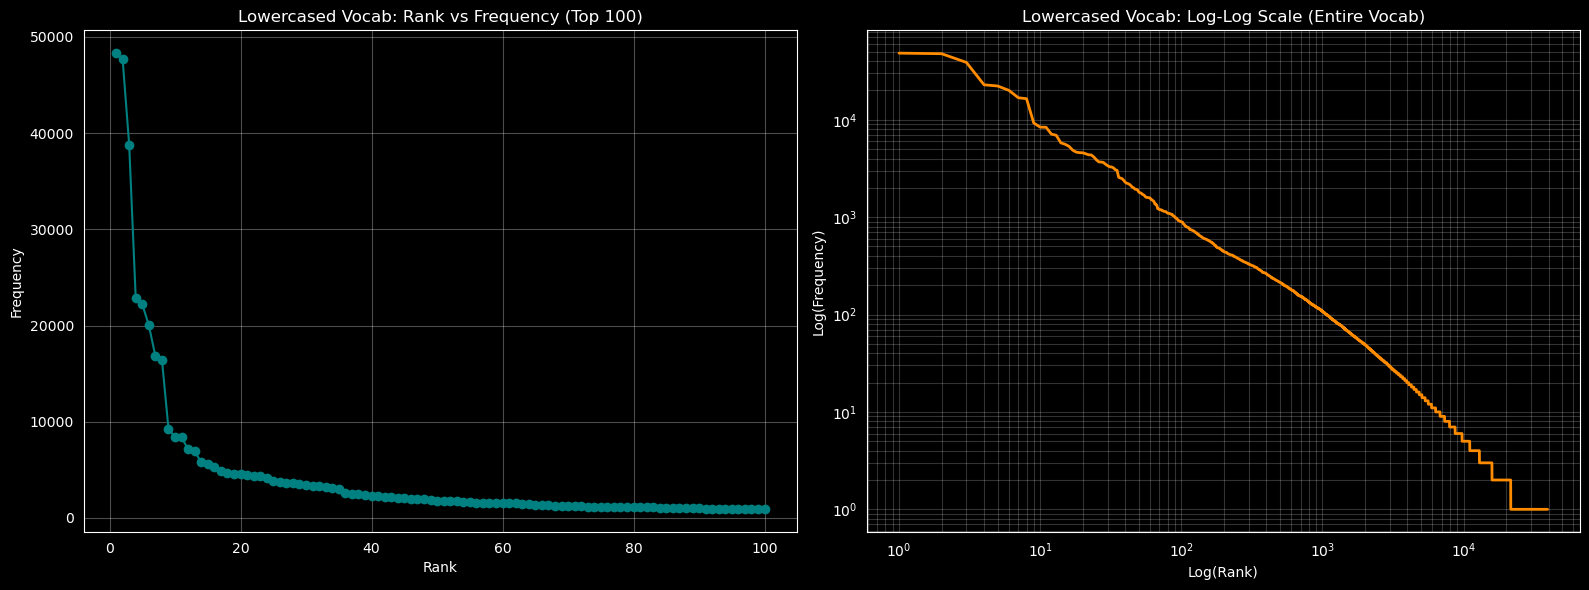

In [8]:
## YOUR CODE HERE ##
def plot_zipf_distribution(vocab_counter: Counter, title: str, cutoff=100) -> None:
    # Extract frequencies and sort them in descending order
    frequencies = sorted(vocab_counter.values(), reverse=True)
    ranks = np.arange(1, len(frequencies) + 1)

    plt.figure(figsize=(16, 6))

    # Subplot 1: Linear Scale (First 'cutoff' words)
    plt.subplot(1, 2, 1)
    plt.plot(ranks[:cutoff], frequencies[:cutoff], marker='o', color='teal')
    plt.title(f"{title}: Rank vs Frequency (Top {cutoff})")
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)

    # Subplot 2: Log-Log Scale (Full Corpus)
    plt.subplot(1, 2, 2)
    plt.loglog(ranks, frequencies, color='darkorange', linewidth=2)
    plt.title(f"{title}: Log-Log Scale (Entire Vocab)")
    plt.xlabel("Log(Rank)")
    plt.ylabel("Log(Frequency)")
    plt.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()
# Generate plots for both corpora
plot_zipf_distribution(initial_vocab, "Initial Vocab")
plot_zipf_distribution(lower_vocab, "Lowercased Vocab")

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

Yes, they seem to follow Zipf's law.

### (b) Tags & tokens [4pt]

**Print** a list of the **10 most commonly occurring POS tags** in the data. For each of these POS tags, additionally **print** the **3 most common token types** (i.e., words) that belong to that tag. Print raw counts for each printed tag and token type.

In [9]:
## YOUR CODE HERE ##
# Use the following printing format and test your numbers for the DT pos tag:
# DT (82147):	the(40831); a(19151); The(6753)

pos_tag = Counter()
tag_to_word = defaultdict(Counter)


for sent in sentences:
    for token, tag in sent:
        pos_tag[tag] += 1
        tag_to_word[tag][token] += 1

print(tag_to_word)
top_counts = pos_tag.most_common(10)

#print(f"{'POS Tag':<10} | {'Count':<10} | {'Top 3 Tokens (Counts)'}")
#print("-" * 70)


for tag, count in top_counts:
    top_tokens = tag_to_word[tag].most_common(3)

    token_string = "; ".join([f"{t} ({c})" for t, c in top_tokens])
    print(f"{tag} ({count}):\t{token_string}")

defaultdict(<class 'collections.Counter'>, {'IN': Counter({'of': 22778, 'in': 14852, 'for': 7907, 'on': 4965, 'that': 4719, 'by': 4438, 'from': 4437, 'at': 4312, 'with': 4210, 'as': 3483, 'In': 1729, 'than': 1599, 'about': 1522, 'because': 973, 'into': 917, 'after': 911, ':': 814, 'if': 808, 'over': 697, '--': 640, 'through': 545, 'under': 530, 'against': 495, 'between': 473, 'while': 470, 'before': 465, 'For': 459, 'since': 451, 'If': 381, 'like': 377, 'during': 367, 'out': 344, 'At': 337, 'As': 321, 'among': 307, 'until': 269, 'up': 264, 'whether': 256, 'without': 245, 'On': 219, 'While': 189, 'though': 188, 'around': 174, 'within': 168, 'After': 162, 'With': 153, 'via': 147, 'Although': 144, 'By': 141, 'down': 139, 'above': 138, 'Under': 133, 'toward': 132, 'despite': 130, 'below': 130, 'although': 124, 'ago': 113, 'off': 110, 'so': 108, 'Among': 108, 'Since': 104, 'per': 93, 'along': 91, 'Because': 88, 'near': 81, 'next': 79, 'Despite': 77, 'behind': 76, 'across': 71, 'During': 69,

### (c) Ambiguity [4pt]

A single token type (i.e. word) may occur with several POS tags. For example, *record* can be both a **noun** *(buy a record)* or a **verb** *(record a lecture)*. This makes POS tags extremely useful for **disambiguation**.

**Print** the percentage(!) of the **ambiguous** words in the vocabulary(!) (i.e. token types that have more than one POS tag?).  

Ambiguous words do not account for a great percentage of the vocabulary. Yet they are among the most commonly occurring words in the English language.  
**Print** the percentage of the dataset that is ambiguous (i.e., counting tokens of ambiguous token types/words wrt data size).  
(Don't round percentages when printing)

**Print** the **10 most frequently shared POS tag pairs** (i.e. POS tag pairs that share most words).  
**Print** the **4 most ambiguous** words (i.e. based on the number of POS tags it can get)

In [10]:
## YOUR CODE HERE ##
# TEST: There are 1060 token types whose tokens get both ('VBD', 'VBN') tags
# TEST: in other words, a set of tokens with VBD and a set of tokens with VBN share 1060 elements

# print in the following way:
# Print ambiguous tokens and tag pairs as, where tags are ordered alphabetically:
# Top 10 confused tag pairs:
#	('VBD', 'VBN') share 1060 tokens
#   ...
#
# Top 4 ambiguous tokens:
# 	token: [POS_1, ..., POS_n]
#   ...
ambiguous_words = {w for w, tags in token_to_tags.items() if len(tags) > 1}

vocab_size = len(initial_vocab_set)
ambiguous_size = len(ambiguous_words)
percentage_ambiguous = (ambiguous_size / vocab_size) * 100

total_tokens = sum(initial_vocab.values())
ambiguous_tokens_count = sum(initial_vocab[w] for w in ambiguous_words)
percent_ambiguous_dataset = (ambiguous_tokens_count / total_tokens) * 100


print(f"Percentage of ambiguous words in vocabulary: {percentage_ambiguous}%")
print(f"Percentage of dataset that is ambiguous: {percent_ambiguous_dataset}%")
print("\n" + "-"*30 + "\n")


tag_pair_counts = Counter()
for tags in token_to_tags.values():
    if len(tags) > 1:
        for pair in combinations(sorted(list(tags)), 2):
            tag_pair_counts[pair] +=1

print("Top 10 confused tag pairs:")
for pair, count in tag_pair_counts.most_common(10):
    print(f"\t{pair} share {count} tokens")

most_ambiguous = sorted(token_to_tags.items(), key=lambda x: len(x[1]), reverse=True)[:4]
print("\nTop 4 ambiguous tokens:")

for token, tags in most_ambiguous:
    print(f"\t{token}: {sorted(list(tags))}")


Percentage of ambiguous words in vocabulary: 13.469803211942999%
Percentage of dataset that is ambiguous: 55.079005800643756%

------------------------------

Top 10 confused tag pairs:
	('VBD', 'VBN') share 1060 tokens
	('JJ', 'NN') share 962 tokens
	('NN', 'VB') share 775 tokens
	('VB', 'VBP') share 752 tokens
	('NN', 'NNP') share 627 tokens
	('JJ', 'VBN') share 456 tokens
	('NN', 'VBP') share 403 tokens
	('NN', 'VBG') share 378 tokens
	('NNS', 'VBZ') share 364 tokens
	('JJ', 'NNP') share 297 tokens

Top 4 ambiguous tokens:
	set: ['JJ', 'NN', 'VB', 'VBD', 'VBN', 'VBP', 'VBZ']
	many: ['DT', 'JJ', 'NN', 'NP', 'PDT', 'RB', 'VB']
	open: ['JJ', 'NN', 'RB', 'RP', 'VB', 'VBP', 'VBZ']
	down: ['IN', 'JJ', 'NN', 'RB', 'RBR', 'RP', 'VBP']


### (d) Explain [4pt]

**Take one** of the 4 most ambiguous words and for **each** of its possible POS tags **give** a sentence/phrase from the **training data** that shows the use of the token with its POS tag.  
For the other **three** words, **pick** one POS tag that seems to you least likely for the word and give the corresponding sentence/phrase from the training data.  
From these examples, **discuss** those that you find it somewhat surprisong or unexpected, supporting your response with reasoning.      
Consult [Figure 17.2](https://web.stanford.edu/~jurafsky/slp3/17.pdf#page=4) for the interpretation of the POS tags. If you would like a more detailed explanation of the POS tags, consult [this technical report](http://www.cs.cmu.edu/afs/cs/Web/People/dgovinda/pdf/semantics/tagguide.pdf). Of course, you don't need to read it entirely, just use it to search for certain POS tags in it.

In [11]:
# Optional code cell for searching certain toke-tag pairs in the training data

target_words = {
    "set":  ["JJ", "NN", "VB", "VBD", "VBN", "VBP", "VBZ"],
    "many": ["VB"],
    "open": ["RP"],
    "down": ["RB"],
}


examples = {}

for sent in sentences:
    for i, (token, tag) in enumerate(sent):
        key = (token, tag)
        if token in target_words and tag in target_words[token] and key not in examples:
            # Reconstruct readable sentence (tokens only)
            readable = " ".join(t for t, _ in sent)
            examples[key] = readable

for (word, tag), sent in sorted(examples.items()):
    print(f"{word}/{tag}:\n\t{sent}\n")


down/RB:
	One hundred and ninety two former greats , near greats , hardly knowns and unknowns begin a 72-game , three-month season in spring-training stadiums up and down Florida .

many/VB:
	Like many of his colleagues , he did n't serve in Vietnam in the 1960s yet embraced a hawkish defense and foreign policy -- even voting against a 1984 resolution critical of the U.S. mining of Nicaraguan harbors .

open/RP:
	Perhaps most exciting , the device is thrusting open a window to the workings of the brain .

set/JJ:
	-LCB- A futures contract is an agreement to buy or sell a commodity or financial instrument at a set price on a specified date .

set/NN:
	Just the thing for the Vivaldi-at-brunch set , the yuppie audience that has embraced New Age as its very own easy listening .

set/VB:
	The National Transportation Safety Board ruled that pilots failed to set the plane 's wing flaps and slats properly for takeoff and failed to make mandatory preflight checks that would have detected the er

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

For the token "set," which appears with seven different POS tags in the training data, its usage ranges from an adjective (JJ) in the context of "at a set price" to a noun (NN) describing a social "set," as well as several verbal forms including the base verb (VB) "to set the plane's wing flaps," the past tense (VBD) where the "announcement set off" a howl and the past participle (VBN) in "hasn't been set". It also appears as VBP in "prosecutors set" and VBZ in "the SEC set," the latter of which is particularly surprising given the lack of a third-person singular suffix.

Regarding the other tokens from the ambiguity list, "many" is labeled as a verb (VB) in the training data within the
phrase "Like many of his colleagues," a result that is unexpected as it clearly functions as a quantifier or
adjective in this context, suggesting an annotation error or noise in the gold-standard corpus. The token "open" is categorized as a particle (RP) in the phrase "thrusting open a window," while "down" appears as an adverb (RB) in the spatial description "up and down Florida". These examples reveal that even established data like the Penn Treebank contains anomalies, such as the VBZ tag for "set" and the VB tag for "many," which highlight the complexity of disambiguating tokens that do not follow standard inflectional morphology or exist in compressed grammatical contexts within the newspaper articles.

## Ex 1.2 [5pt]

You are also provided with another file called **sec00.gold.tagged**.
Section 00 of the Penn Treebank is typically used as development data.

### (a) Unseen % [3pt]

**Print** the percentages and the raw count of the **unseen development vocabulary** and **unseen development data** (i.e., token types and tokens that occur in the development data but not in the training data). Percentages should be calculated wrt the development vocabulary/data size and they shouldn't be rounded.

In [12]:
## YOUR CODE HERE ##
# Use PTB_FILES global var
# print as
# Unseen vocab percentage = X1% (X2)
# Unseen data percentage = Y1% (Y2)
# TEST: Difference between the percentages (X1-Y1) should be in the interval 10-15%

development_vocab = Counter()
unseen_dev_tokens_count = 0

with open(PTB_FILES['dev'], 'r') as dev_file:
    for line in dev_file:
        pairs = line.strip().split()
        for tp in pairs:
            token, tag = tp.rsplit("|", 1)

            development_vocab[token] += 1

            if token not in initial_vocab_set:
                unseen_dev_tokens_count += 1

# Raw counts + totals
total_dev_tokens = sum(development_vocab.values())
dev_vocab_set = set(development_vocab.keys())

# Unseen vocabulary:
unseen_vocab_types = dev_vocab_set - initial_vocab_set
unseen_vocab_count = len(unseen_vocab_types)

# Percentages
unseen_vocab_percent = (unseen_vocab_count / len(dev_vocab_set)) * 100
unseen_data_percent = (unseen_dev_tokens_count / total_dev_tokens) * 100

print(f"Unseen vocab percentage = {unseen_vocab_percent}% ({unseen_vocab_count})")
print(f"Unseen data percentage = {unseen_data_percent}% ({unseen_dev_tokens_count})")

diff = unseen_vocab_percent - unseen_data_percent
print(f"\nTEST: Difference is {diff:.2f}%. (Should be between 10-15%)")

Unseen vocab percentage = 16.34932724041635% (1288)
Unseen data percentage = 3.804323895909471% (1728)

TEST: Difference is 12.55%. (Should be between 10-15%)


### (b) Unseen tok tag [2pt]

**Print** the top **five** POS tags that the most **unseen tokens** belong to.

In [13]:
## YOUR CODE HERE ##
# Print in the following format:
# POS_tag (the_number_of_corresponding_unseen_tokens)

unseen_tag_counter = Counter()

with open(PTB_FILES['dev'], 'r') as dev_file:
    for line in dev_file:
        pairs = line.strip().split()
        for tp in pairs:
            token, tag = tp.rsplit("|", 1)

            if token not in initial_vocab_set:
                unseen_tag_counter[tag] += 1

print("Top five POS tags for unseen tokens:")
top_5_unseen_tags = unseen_tag_counter.most_common(5)

for tag, count in top_5_unseen_tags:
    print(f"{tag} ({count})")

Top five POS tags for unseen tokens:
NNP (815)
JJ (258)
NN (210)
NNS (146)
CD (114)


## Work description for Ex 1

~~Describe your approach to solving the exercises, for example, what steps you took first, followed by subsequent actions, which parts you found most challenging or easy, any specific helpful assistance received from TAs, whether you used GenAI, to what extent, at what stage, which one, how helpful was it, etc.~~

YOUR ANSWER HERE [100-200 words]

# 2. Language Models



The following questions presuppose J&M's [chapter 3 on n-gram language models](https://web.stanford.edu/~jurafsky/slp3/3.pdf).

Models that assign **probabilities** to **sequences of words** are called **language
models** or **LMs**. The simplest model that assigns probabilities to sentences and sequences of words is the **N-gram** model.

Recall that an *N*-gram language model uses **conditional probabilities** of the form
    
$$P(w_k \mid w_{k-N+1} \dots w_{k-1})$$

to **approximate** the full **joint probability**

$$P(w_1 \dots w_n)$$

of a sequence of words $w_1 \dots w_n$.

The easiest way of obtaining estimates for the probabilities $P(w_k \mid w_{k-N+1} \dots w_{k-1})$ is to use the **maximum likelihood estimate** or **MLE**, a widely used statistical estimation method ([read more](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation)). You count and normalize:

$$P_{MLE}(w_k \mid w_{k-N+1} \dots w_{k-1}) = \frac{C(w_{k-N+1} \dots w_{k-1} w_k)}{C(w_{k-N+1} \dots w_{k-1})}.$$

## Ex 2.1 [20pt]

In this exercise you will have to train $N$-gram language models with an optional smoothing.

#### Some help

The `collections` library has another useful data structure: the `defaultdict`. Some example uses (learn more [here](https://realpython.com/python-defaultdict/) if needed):

**[Datastructure hint]** If you store the smoothed language in a naive manner (that is, to store *all* the numbers separately) your datastructure will get huge! If $V$ is the vocabulary then the smoothed bigram model assigns probabilities to $|V|^2$ entries. If $|V|$ is around 80k, the naive way requires you to store more than 64 billion floats. Yet almost all of these are actually just $P(w_n|w_{n-1}) = \frac{k}{N + k|V|}$, with $k$ the value with which you smooth and $N=C(w_{n-1})$. Think about how you use this fact to make your model work in practice.

In [1]:
from collections import defaultdict

d = defaultdict(float)
d["new key"]

0.0

Compare that to an ordinary dictionary:

In [ ]:
# d = dict()
# d["new key"]
# Throws an KeyError: 'new key'

Other datatypes as `default_factory`:

In [ ]:
d = defaultdict(int)
print(d)
print(d["new key"])
print(d)

In [ ]:
d = defaultdict(list)
print(d)
print(d["new key"])
print(d)

Note how the defaultdict is modified after getting a value of a non-existing key. If you want to avoid modifying the defaultdict when getting a value for a non-existing key, do the following:

In [ ]:
d = defaultdict(list)
print(d)
print(d.get("new key", d.default_factory()))
print(d)

Converting an already existing `dict`:

In [ ]:
d1 = {k: "value" for k in range(1, 11)}
d = defaultdict(float, d1) # convert it to a defaultdict
print(d[5])
print(d[100])

This doesn't work:

In [ ]:
# d = defaultdict(10)
# Throws a TypeError: first argument must be callable or None

Use a `lambda` to make the number `10` `callable`":

In [ ]:
d = defaultdict(lambda: 10)
print(d)
print(d["new key"])
print(d)

In [ ]:
d = defaultdict(lambda: defaultdict(float))
print(d)
print(d["new key"])
print(d)

Note that in some cases the behaviour of lambda functions might be counterintuitive. One of such cases is the closure: [link1](https://realpython.com/python-lambda/#closure), [link2](https://stackoverflow.com/questions/2295290/what-do-lambda-function-closures-capture).

In [14]:
# making a shortcut for the read-only get for defaultdict that supports several keys
# i.e. defget(d, [k1, k2]) will return the value of d[k1][k2] without altering d
def defget(d, keys):
    for k in keys:
        d = d.get(k, d.default_factory() if isinstance(d, defaultdict) else 0)
    return d

# testing if it works as intended
d = defaultdict(lambda: defaultdict(int))
d[1][1] = 2
d[2][1] = 3
print(d)
print(defget(d, [1, 1]))
print(defget(d, [3]))
print(defget(d, [3, 1]))
print(d)

defaultdict(<function <lambda> at 0x7a3d5006b4c0>, {1: defaultdict(<class 'int'>, {1: 2}), 2: defaultdict(<class 'int'>, {1: 3})})
2
defaultdict(<class 'int'>, {})
0
defaultdict(<function <lambda> at 0x7a3d5006b4c0>, {1: defaultdict(<class 'int'>, {1: 2}), 2: defaultdict(<class 'int'>, {1: 3})})


Clever use of a `defaultdict` can be the solution to the problem of data-storing in a smoothing $N$-gram pointed out above:
    
    d = bigram_frequencies[history] = {w1: 120, w2: 340, w3: 7 ...}
    N = sum(d.values())
    # d_normalized = .... # normalize d with smoothing applied to elements already in the dictionary  
    d_smoothed = defaultdict(lambda: k/(N + kV), d_normalized) # add smoothing to 'unseen' words

The following function is given to assist you with reading the data from the file in a convenient format. Understand how the function works and figure out how to use it for training n-grams.

Note that the function uses padding symbols `<s>` and `</s>` to mark sentence boundaries. **Include `</s>` in the vocabulary (for unigram models too)** which will serve as an indicator of stopping the sentence generation when doing word-by-word sampling (Ex 2.2).

In [15]:
def read_data(fname, h=1, max_lines=np.inf):
    """
    Reads in the data from a file and returns a vocabulary as a set
    and the sentence-padded data as a list of list.

    :param fname: path to the file
    :param max_lines: the number of top lines to read (can be used for debugging)
    :param h: the length of n-gram history
    :returns: data as a list of lists and vocabulary as a set
    """
    data = []
    start = h * ["<s>"]
    end = ["</s>"]

    with open(fname, "r") as F:
        for k, line in enumerate(F):
            # an optional cut-off to read a part of the data
            if k > max_lines:
                break
            words = line.strip().split()
            # padding the sentence
            sent = start + words + end #also adding the ending for unigrams to capture most likley stopping time when generating the sentences
            data.append(sent)
    return data

### train_ngram

**Complete** the function `train_ngram` so that you can train a count-based $N$-gram language model on the data found in `data/ted-train.txt` and train this for $N=2,3$.

**Extend** the function `train_ngram` so that it accepts a parameter `k` for optional add-$k$ smoothing (upgrade the same function, don't define new). <font color="red">For smoothing, in case of histories unseen in the data, use the unigram model instead of the uniform distribution.</font>

Note that `ngram` should be a defaultdict of defaultdict because it should return a value for any history and for any next word combination. However, `unigram` need to be a defaultdict with float values as it takes no history into account.

In [16]:
def train_ngram(data, N=2, k=0):
    """
    Trains an n-gram language model with optional add-k smoothing
    and additionally returns the unigram model

    :param data: text-data as returned by the pre-defined function read_data
    :param N: (N>1) the order of the ngram e.g. N=2 gives a bigram
    :param k: optional add-k smoothing
    :returns: ngram and unigram
    """
    # ngram[history][word] = #(history,word)
    # for history of length >1, join tokens with a singel white space (see tests below)

    ## YOUR CODE HERE ##
    ## you can have auxiliary functions if needed, inside this function

    ngram_counts = defaultdict(Counter)
    unigram_counts = Counter()
    total_tokens = 0

    vocab = set()
    for sent in data:
        for i in range(len(sent)):
            token = sent[i]
            unigram_counts[token] += 1
            total_tokens += 1
            vocab.add(token)

            if i>= N - 1:
                history = " ".join(sent[i-(N-1):i])
                ngram_counts[history][token] += 1
    vocab_size = len(vocab)

    return ngram, unigram

In [ ]:
# This shouldn't take more than 2min
Data1 = None ## YOUR CODE HERE ##
# use the global variable for the file path
# non-smoothed bigram
Bigram, Unigram = train_ngram(Data1, N=2, k=0)
# smoothed bigram
Bigram_sm, Unigram_sm = train_ngram(Data1, N=2, k=1)

In [ ]:
# Running this might take significant amount of memory
# Runtime shouldn't take more than 3min
Data2 = None ## YOUR CODE HERE ##
# non-smoothed trigram
Trigram, Unigram_ = train_ngram(Data2, N=3, k=0)
# smoothed trigram
Trigram_sm, Unigram_sm_ = train_ngram(Data2, N=3, k=1)

<font color="red">Obviously, these tests are not complete. You are encouraged to design your own tests, but comment them out or delete them before the submission.</font>

In [ ]:
#TEST 2.1
# Be aware that when getting a value of a non-existing key from defaultdict with d[key] method,
# the key gets inserted into the defaultdict. That's why tests use defget
assert defget(Bigram, ['all','people']) > 0
assert defget(Bigram, ['all','all']) == 0
assert defget(Bigram_sm, ['all','all']) == defget(Bigram_sm, ['all','asdasda'])
assert defget(Bigram_sm, ['all','asdasda']) > 0
assert defget(Trigram, ['<s> <s>','The']) > 0
assert defget(Trigram, ['<s> <s>','sun']) == 0
assert np.isclose(sum(Trigram['All the'].values()), 1) #almost 1, but not 1 because of float point rounding
assert defget(Trigram_sm, ['<s> <s>','sun']) > 0
assert defget(Unigram, ['</s>']) > 0
assert Unigram == Unigram_
assert Unigram_sm == Unigram_sm_

## Ex 2.2 [5pt]

You can use an *N*-gram language model to **generate text**. The higher the order *N* the better your model will be able to catch the long-range dependencies that occur in actual sentences and the better your chances are at generating sensible text. But beware: **sparsity** of language data will quickly cause your model to reproduce entire lines from your training data; in such cases, only one $w_k$ was observed for the histories $w_{k-N+1}\dots w_{k-1}$ in the entire training set.

### Some help

**[Hint]** You can use the method of [inverse transform sampling](https://en.wikipedia.org/wiki/Inverse_transform_sampling) to generate a sample from a **categorical distribution**, $p_1\dots p_k$ such that $p_i \geq 0$ and $\sum_{i=1}^k p_i = 1$, as follows:

In [ ]:
import random

P = [0.2,0.5,0.2,0.1]

def sample(P):
    u = random.random() # random number between 0 and 1
    p = 0
    for i, p_i in enumerate(P):
        p += p_i
        if p > u:
            return i # the first i s.t. p1 + ... + pi > u

print(sample(P))

print(Counter([sample(P) for i in range(1000)])) # check to see if the law of large numbers is still true

Inverse transform sampling in the words of Jurafsky and Martin:

> Imagine all the words of the English language covering the probability space
between 0 and 1, each word covering an interval proportional to its frequency. We
choose a random value between 0 and 1 and print the word whose interval includes
this chosen value.

(J&M, [section 3.3](https://web.stanford.edu/~jurafsky/slp3/3.pdf#page=10))

### generate_sent

**Complete** the function `generate_sent`. It takes a language model `lm` and an order `N` and should generate a **natural language string(!)** (it shouldn't contain padding symbols and might not be a grammatical sentence) by **sampling** from the language model.

In [ ]:
def generate_sent(lm, N):
    """
    Generates sentence from a language model based on N-grams
    :param lm: language model based on N-grams
    :param N: denoting N-gram parameter
    :returns: a string of natural language text
    """

    ## YOUR CODE HERE ##
    ## you can have auxiliary functions if needed, inside of outside this function's scope
    ## don't forget to reuse "sample" function defined above

    raise NotImplementedError("Function not implemented yet")

In [ ]:
#TEST Ex2.2
random.seed(2025) #uncommnet if you want to make the output non-deterministic

print("Bigram:\n")
print("\n".join([generate_sent(Bigram, 2) for _ in range(5)]))

print("\nTrigram:\n")
print("\n".join([generate_sent(Trigram, 3) for _ in range(5)]))

### [Extra]
No points for this

For how many of the histories $w_{k-N+1}\dots w_{k-1}$ is the number of continuations $w_n$ equal to **one**? Calculate the percentage of such cases for the different orders *N*.

And which history has the **most possible continuations**?

In [ ]:
## YOUR CODE HERE ##

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

## Ex 2.3 Train sent. prob. [5pt]

**Recall** that if we have a sentence $w_1,\dots,w_n$ we can write

$$P(w_1\dots w_n) = P(w_1)P(w_2|w_1) \cdots P(w_n|w_1 \dots w_{n-1}) \approx P(w_1)P(w_2|w_1)\cdots P(w_n|w_{n-(N-1)}\dots w_{n-1})\prod_{i=1}^{n} P(w_i|w_{i-(N-1)}\dots w_{i-1})$$

where in the last step we make an $N$-gram approximation of the full conditionals.

For example, in the case of a bigram (N=2), the above expression reduces to

$$P(w_1 \dots w_n)\approx P(w_1)\prod_{i=2}^{n} P(w_i| w_{i-1}).$$

The following sentences are taken from the **training data**. Use your **unsmoothed unigram**, **bigram**, and **trigram** language model to estimate their **probabilities**:

    1. Every day was about creating something new .
    2. In this machine , a beam of protons and anti-protons are accelerated to near the speed of light and brought together in a collision , producing a burst of pure energy .

In [ ]:
def sent_prob(sent, lm, N):
    """
    Calculates probability of sent based on the N-gram language mode lm
    :param sent: tokenized sentence string
    :param lm: N-gram language model
    :param N: N-gram size
    :returns: probabilitity number
    """
    ## YOUR CODE HERE ##

    return prob

In [ ]:
# Print all the abovemnetioned probabilities (NOT log probabilities).
# The cell output should make it clear what number stands for which probability.
# Reuse the variables Unigram, Unigram_sm, Bigram, Bigram_sm, Trigram, and Trigram_sm.
# Note that sent_prob should take a sentence input as a string, not as a list.

Sents_from_train = (
    "Every day was about creating something new .",
    "In this machine , a beam of protons and anti-protons are accelerated to near the speed of light and brought together in a collision , producing a burst of pure energy ."
)

## YOUR CODE HERE ##

**Repeat** this with the **smoothed (add-1)** versions of the N-grams (in the same above code cell).   
**What** is the effect of smoothing on the probabilities and **how** the effect compare across the different $N$-grams models? Provide explanations for the effect and the comparison.

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

## Ex 2.4 Test sent. prob. [3pt]

The above sentences were taken from the training set, hence they will all have a probability greater than 0. The big challenge for our language model are of course with the sentences that contain unseen N-grams: if such an N-gram occurs our model immediately assigns the sentence probability zero.

The following sentences are taken from the **test set** available in the file **ted-test.txt**.  
**Print** the probabilities of the sentences based on the smoothed and unsmoothed language models.

    1. Because these robots are really safe .
    2. We have sheer nothingness on one side , and we have this vision of a reality that encompasses every conceivable world at the other extreme : the fullest possible reality , nothingness , the simplest possible reality .

In [ ]:
# Print all the abovemnetioned probabilities.
# The cell output should make it clear what number stands for which probability.
# Reuse the variables Unigram, Unigram_sm, Bigram, Bigram_sm, Trigram, and Trigram_sm.
# Note that sent_prob should take a sentence input as a string, not as a list.

Sents_from_test = (
    "Because these robots are really safe .",
    "We have sheer nothingness on one side , and we have this vision of a reality that encompasses every conceivable world at the other extreme : the fullest possible reality , nothingness , the simplest possible reality ."
)
### YOUR CODE HERE ###

**Contrast** the smoothed and unsmoothed probabilities and **explain** the drastic changes (if any) in terms of unseen tokens and sequences.

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

### [Extra]

**Optional** What percentage of the sentences in the test set get assigned probability 0 under your smoothed and unsmoothed language models?

In [ ]:
### ANSWER HERE ###

## Ex 2.5 Critical reflection [4pt]

We have implemented $n$-gram models with the help of `defaultdict`, which helps us to save on memory. This implementation differs from the standard approach that uses `<UNK>` tokens for unseen words. Given this, what serious theoretical issue do our implementation of $n$-gram models have?

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

## Ex 2.6 Perplexity [7pt]

**Perplexity** is a very frequently used **metric** for evaluating probabilistic models such as language models. The perplexity (sometimes called **PP** for short) of a language model on a sentence is the **inverse probability** of the sentence, **normalized** by the number of words:

$$PP(w_1 \dots w_n) = P(w_1\dots w_n)^{-\frac{1}{n}}.$$

Here we can again approximate $P(w_1 \dots w_n)$ with N-gram probabilities, as above.

Note: Calculation of perplexity has a resemblance with the **geometric mean** $(x_1\cdots x_n)^{-\frac{1}{n}}$ of the numbers $x_1,\dots,x_n$. It is like the (regular) arithmetic mean, but with **products** instead of **sums**. The geometric mean is a more natural choice in the case of *PP* because behind $P(w_1\dots w_n)$ is a series of $n$ products ([more here](https://en.wikipedia.org/wiki/Geometric_mean)).



Compute the perplexity of the sample sentences from the training and test data (`Sents_from_train` and `Sents_from_test` from Ex2.3-4) based on the smoothed bigram language model. It is recommended to use `sent_prob` from Ex 2.3.

What big difference between the **probabilities** of the sentences and the **perplexities** of the sentences do you notice?  
**Support** your answer with additional, stronger evidence, such as a plot based on more sentences or the entire data, and further **explain** the difference.

In [ ]:
# Feel free to reuse functions and variables form the previous exercises
# use Sents_from_train and Sents_from_test
### YOUR CODE HERE ###

<font color="red">█████ ANSWER UNDER THIS LINE █████</font>

## Work description for Ex 2

~~Describe your approach to solving the exercises, for example, what steps you took first, followed by subsequent actions, which parts you found most challenging or easy, any specific helpful assistance received from TAs, <font color="red">whether you used GenAI, to what extent, at what stage, which one, how helpful was it</font>, etc.~~

YOUR ANSWER HERE [100-200 words]

# That's it!

Congratulations, you have made it to the end of the tutorial. Here we will recap the gist of this notebook.

**Make sure all your cells can be executed and all your answers are there. Then, read on if you're interested!**

-----

By now you should have a solid feeling for the problem of **sparsity in language data**; there's just never enough data. For the task of language modelling, we saw that sparsity is a serious challenge.

It would be great to be able to model $p(w_n|w_1 \dots w_{n-1})$ for unlimited $n$: the larger $n$ the better our language model should become at capturing the long-range dependencies between words that characterize actual human sentences, and the more probability our model will assign to such sentences as opposed to sentences that are word-soup. But in the N-gram approach, increasing $n$ will quickly kill all generalizing abilities of the model: the model will start to assign probabilities only to sentences it has seen in the training data.

So, where to go from here? Here are three directions that we could head in.

### Smoothing

We have seen one example of smoothing in this lab: add-k smoothing. This is an easy method, both conceptually and implementation-wise. But the results are not great, and the effects it has on the distributions can be extreme.

A much more sophisticated method of smoothing is **Kneser-Ney smoothing**. The method is described in detail in section 4.5 of J&M (3rd edition). This is one of the best-performing N-gram smoothing methods, and up to a few years ago, a popular implementation of it called [KenLM](https://kheafield.com/code/kenlm/) gave state-of-the-art results.

### From words to characters

In this lab we have considered language modeling as the task of predicting a **word** $w_n$ based on a history of **words** $w_1\cdots w_n$. What if instead we let our basic units of modelling be **characters**? The task then becomes to model $p(c_k\mid c_{k-N-1}\dots c_{k-1})$ where each $c_i$ is now an ASCII character instead of an entire word.

Suddenly sparsity of data is no longer a problem! The set of characters to use is tiny (< 100) compared to even a small-sized vocabulary as today. Have a look at this very illustrative notebook written by Yoav Golberg to see such a method in action: [The unreasonable effectiveness of Character-level Language Models](http://nbviewer.jupyter.org/gist/yoavg/d76121dfde2618422139).

(So what is the downside?)


### Neural language models

The above notebook was actually written as a response to this blog post by Andrej Karpathy: [The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/). Go ahead and read it if you haven't already: it is a superb introduction to the topic of Recurrent Neural Networks.

Neural language models solve the problem of data sparsity in a different manner. Instead of estimating the probabilities $p(w_k\mid w_{k-N-1}\dots w_{k-1})$ by counting occurrences in the data, they use a neural network $f_{\theta}$ parametrized by parameters $\theta$ to predict this probability. The parameters $\theta$ are learned through optimization.

The simplest approach goes like this: each word in the history $w_{k-N-1}\dots w_{k-1}$ is embedded separately giving vectors $e_{k-N-1}\dots e_{k-1}$ and then concatenated into one long vector $[e_{k-N-1};\dots ;e_{k-1}]$. The network then uses this history vector to predict a probability distribution over words $w$ in the vocabulary $V$:

$$p(w \mid w_{k-N-1}\dots w_{k-1}) = f_{\theta}([e_{k-N-1};\dots;e_{k-1}]).$$

(In order to produce legitimate probabilities the final layer of such a network will be for example a $softmax$.)

This provides a solution to the sparsity problem by having the network let the individual embeddings of the words in the history interact through its non-linear transformation. We are letting the network figure out the smoothing itself!

RNNs are a clever extension of this idea, where a hidden state vector $h$ is re-used and updated at each step $k$ in order to store the information of the entire history up to step $k-1$. That is, an RNN actually does away with the N-order approximation; it tries to model the full conditional directly! That means that

$$p(w \mid w_1\dots w_{k-1}) \approx RNN_{\theta}([e_{k-1};h_{k-1}])$$

where the hidden state $h_{k-1}$ is a compression of the *entire history* $w_1\dots w_{k-1}$.

Another great place to learn about RNNs, their problems, and solutions to those, is on the blog of [Christopher Olah](http://colah.github.io/posts/2015-08-Understanding-LSTMs/).

-----------
(And now, it's time to read the classic essay by Eugene Wigner that gave both of the posts their title: [The Unreasonable Effectiveness of Mathematics in the Natural Sciences](http://www.dartmouth.edu/~matc/MathDrama/reading/Wigner.html))

# Acknowledgments

Most of this lab was developed in collaboration with Joost Bastings and Dan Douwe.  
Later it was revised by a couple of people.  
The recent updates by Lasha Abzianidze make the notebook more streamlined and foolproof from the grading and the large course perspectives.